# Hito 3 - Explicabilidad del Modelo con SHAP
## GuardianAI - Deteccion Inteligente de Fraude Bancario

## Indice

1. Importacion de librerias
2. Reconstruccion del pipeline
   - 2.1. Carga y particion de datos
   - 2.2. Codificacion, escalado y SMOTE
   - 2.3. Entrenamiento del modelo XGBoost
3. Que es SHAP y por que se usa
4. Calculo de valores SHAP
5. Interpretacion global: Summary Plot
6. Interpretacion local: Waterfall Plot
7. Analisis critico de los resultados
8. Conclusiones del analisis de explicabilidad

## 1. Importacion de librerias

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

os.makedirs('../figures', exist_ok=True)

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 10
})

## 2. Reconstruccion del pipeline

Este notebook es independiente de NB03. Para poder calcular los valores SHAP necesitamos el modelo entrenado y el conjunto de test preprocesado. Se reconstruye aqui el mismo pipeline que en NB03 de forma compacta, usando los mismos parametros de XGBoost para garantizar que el modelo analizado es identico al que se evaluo en ese notebook.

### 2.1. Carga y particion de datos

In [2]:
df = pd.read_csv('Base.csv')
df = df.drop(columns=['credit_risk_score'])

X = df.drop(columns=['fraud_bool'])
y = df['fraud_bool']

# Particion 70/15/15 identica a NB03
X_train_70, X_temp, y_train_70, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_val_15, X_test_15, y_val_15, y_test_15 = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f'Train:      {len(X_train_70):,} registros')
print(f'Validacion: {len(X_val_15):,} registros')
print(f'Test:       {len(X_test_15):,} registros')

Train:      700,000 registros
Validacion: 150,000 registros
Test:       150,000 registros


### 2.2. Codificacion, escalado y SMOTE

In [3]:
# One-hot encoding
X_train_enc = pd.get_dummies(X_train_70, drop_first=True)
X_test_enc  = pd.get_dummies(X_test_15,  drop_first=True)
X_test_enc  = X_test_enc.reindex(columns=X_train_enc.columns, fill_value=0)

# Escalado: ajuste solo sobre train, aplicado a ambos
numeric_cols = X_train_enc.select_dtypes(include='number').columns.tolist()
scaler = StandardScaler()
scaler.fit(X_train_enc[numeric_cols])
X_train_enc[numeric_cols] = scaler.transform(X_train_enc[numeric_cols])
X_test_enc[numeric_cols]  = scaler.transform(X_test_enc[numeric_cols])

# SMOTE solo sobre train
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_smote, y_train_smote = smote.fit_resample(X_train_enc, y_train_70)

print(f'Train tras SMOTE: {len(X_train_smote):,} muestras '
      f'(fraude: {y_train_smote.mean()*100:.1f}%)')
print(f'Test (desbalanceo real): {len(X_test_enc):,} muestras '
      f'(fraude: {y_test_15.mean()*100:.2f}%)')

Train tras SMOTE: 1,384,560 muestras (fraude: 50.0%)
Test (desbalanceo real): 150,000 muestras (fraude: 1.10%)


### 2.3. Entrenamiento del modelo XGBoost

In [4]:
# Modelo con los parametros del NB03
# Si se han obtenido mejores parametros con RandomizedSearchCV,
# sustituir estos valores por los que devolvio busqueda.best_params_
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=1.0,
    reg_lambda=1.0,
    min_child_weight=1,
    random_state=42,
    verbosity=0,
    n_jobs=-1
)

xgb_model.fit(X_train_smote, y_train_smote)
print('Modelo entrenado correctamente.')
print(f'Features disponibles: {X_train_smote.shape[1]}')

Modelo entrenado correctamente.
Features disponibles: 46


## 3. Que es SHAP y por que se usa

XGBoost es un modelo de alta capacidad predictiva pero escasa transparencia: dado que combina cientos de arboles de decision, es practicamente imposible entender a simple vista por que predice fraude en una transaccion concreta. En el sector bancario esto es un problema serio — regulaciones como la GDPR exigen que las decisiones automatizadas sean explicables.

**SHAP** (SHapley Additive exPlanations) resuelve esto aplicando un concepto de la teoria de juegos cooperativos: los **valores de Shapley**. La idea original es esta: imagina que cada variable del modelo es un jugador en un equipo, y la prediccion final es el resultado del equipo. Los valores de Shapley calculan cuanto ha contribuido cada jugador al resultado, probando todas las posibles combinaciones de jugadores y midiendo cuanto cambia el resultado cuando se incluye o se excluye cada uno.

Formalmente, la prediccion de un ejemplo concreto se descompone como:

```
prediccion = valor_base + contribucion(variable_1) + contribucion(variable_2) + ...
```

donde el `valor_base` es la probabilidad media de fraude en el dataset, y cada `contribucion` puede ser positiva (empuja hacia fraude) o negativa (empuja hacia legitima).

**Por que SHAP sobre otros metodos de importancia:**

- La importancia de Gini (usada en NB03) solo dice *cuanto* usa el modelo una variable en promedio, pero no dice *en que direccion* ni *en que casos*.
- SHAP da tanto la magnitud como la direccion de cada variable, tanto a nivel global (comportamiento promedio del modelo) como local (explicacion de una prediccion individual).
- Tiene una base matematica solida: los valores de Shapley son la unica forma de distribuir el credito entre variables que cumple simultáneamente eficiencia, simetria y linealidad.

Para XGBoost se usa `TreeExplainer`, una implementacion eficiente que aprovecha la estructura de los arboles de decision para calcular los valores exactos en tiempo polinomico, sin necesidad de aproximaciones.

## 4. Calculo de valores SHAP

Calcular SHAP sobre el millon de filas del test completo seria muy lento. Se toma una muestra aleatoria representativa de 1000 filas del conjunto de test, suficiente para que los patrones globales sean estables. Esta practica es estandar en la literatura cuando el dataset es grande.

El conjunto de test conserva el desbalanceo original (~1.1% de fraudes), por lo que la muestra puede contener muy pocos fraudes reales. Para los plots globales eso no es problema porque SHAP analiza las contribuciones de las variables independientemente de la clase real. Para el waterfall plot (explicacion local) se selecciona especificamente un caso clasificado como fraude para que la interpretacion sea mas ilustrativa.

In [5]:
# Muestra del conjunto de test para SHAP
N_MUESTRA = 1000
np.random.seed(42)
indices_muestra = np.random.choice(len(X_test_enc), size=N_MUESTRA, replace=False)
indices_muestra = np.sort(indices_muestra)  # acceso secuencial es mas eficiente

X_shap = X_test_enc.iloc[indices_muestra].reset_index(drop=True)
X_shap = X_shap.astype(np.float32)

print(f'Muestra para SHAP: {X_shap.shape[0]} filas x {X_shap.shape[1]} variables')

# Calcular valores SHAP con TreeExplainer
# TreeExplainer es la version rapida especifica para modelos basados en arboles
explainer  = shap.TreeExplainer(xgb_model)
shap_vals  = explainer.shap_values(X_shap, check_additivity=False)

print('Valores SHAP calculados correctamente.')
print(f'Forma de la matriz SHAP: {shap_vals.shape}')
print('(filas = muestras, columnas = variables, valores = contribucion a la prediccion)')

Muestra para SHAP: 1000 filas x 46 variables
Valores SHAP calculados correctamente.
Forma de la matriz SHAP: (1000, 46)
(filas = muestras, columnas = variables, valores = contribucion a la prediccion)


## 5. Interpretacion global: Summary Plot

El summary plot es la visualizacion principal de SHAP para entender el comportamiento global del modelo. Muestra todas las variables ordenadas de mayor a menor importancia media (eje vertical), y para cada variable muestra un punto por cada muestra analizada.

**Como leer este grafico:**

- **Posicion horizontal** de cada punto: valor SHAP de esa variable para esa muestra. Un valor positivo (a la derecha) significa que esa variable empuja la prediccion hacia fraude. Un valor negativo (a la izquierda) empuja hacia legitima.
- **Color de cada punto**: valor real de la variable en esa muestra. Rojo = valor alto de la variable, azul = valor bajo.
- **Anchura de la nube de puntos**: cuanto varia el impacto de esa variable entre distintas muestras. Una nube ancha indica que la variable tiene un impacto muy diferente segun el caso concreto.

Por ejemplo, si `keep_alive_session` aparece en primer lugar y sus puntos rojos estan a la derecha, significa que tener la sesion activa (valor alto) aumenta la probabilidad de fraude segun el modelo.

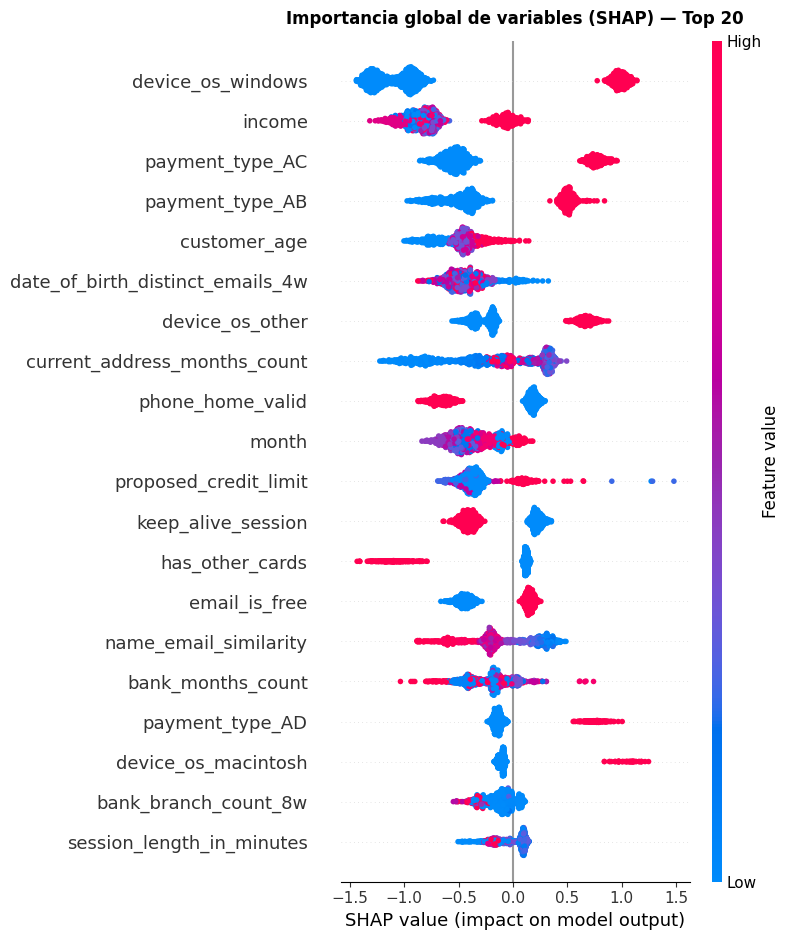

Grafico guardado en ../figures/shap_summary.png


In [6]:
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_vals,
    X_shap,
    max_display=20,
    show=False
)
plt.title('Importancia global de variables (SHAP) — Top 20',
          fontsize=12, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('../figures/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafico guardado en ../figures/shap_summary.png')

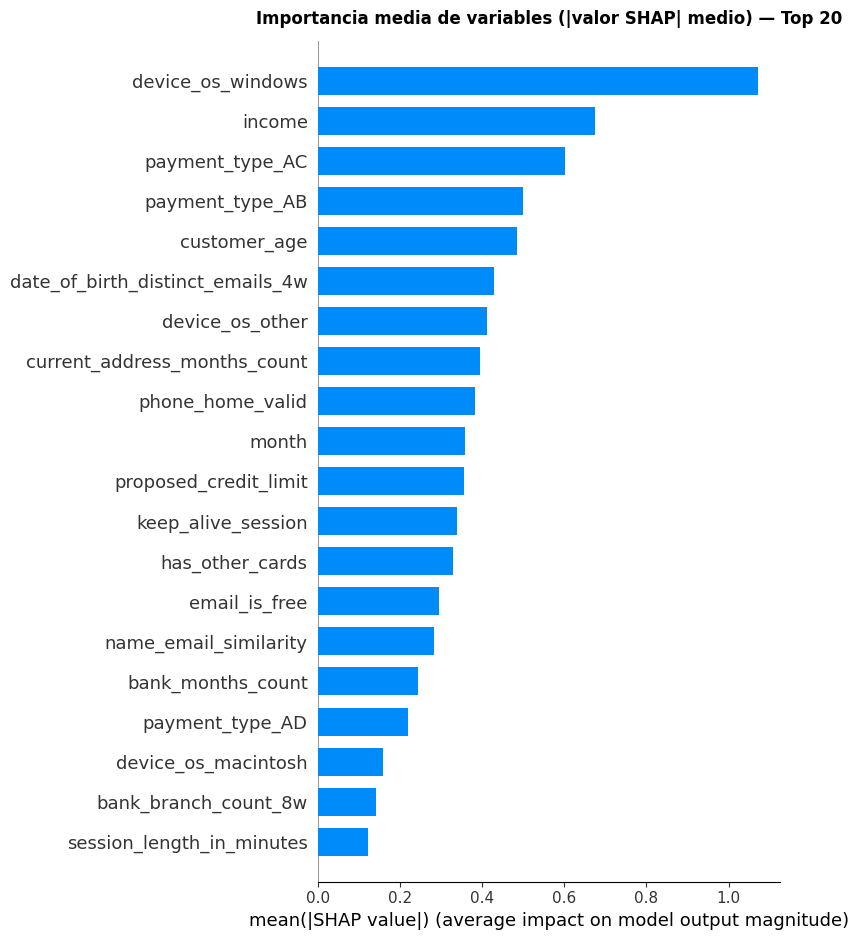

Grafico guardado en ../figures/shap_summary_bar.png


In [7]:
# Version alternativa: grafico de barras con importancia media absoluta
# Mas sencillo de leer para un publico no tecnico
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_vals,
    X_shap,
    plot_type='bar',
    max_display=20,
    show=False
)
plt.title('Importancia media de variables (|valor SHAP| medio) — Top 20',
          fontsize=12, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('../figures/shap_summary_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafico guardado en ../figures/shap_summary_bar.png')

## 6. Interpretacion local: Waterfall Plot

Mientras que el summary plot explica el comportamiento *promedio* del modelo, el waterfall plot explica una prediccion *individual* concreta. Es especialmente util en banca para justificar por que se ha bloqueado una transaccion especifica — algo que puede requerir un auditor o que el propio cliente puede reclamar.

**Como leer este grafico:**

- La barra arranca en el `valor base` (probabilidad media de fraude en el dataset).
- Cada variable suma o resta a ese valor base su contribucion SHAP.
- Las barras rojas empujan hacia fraude (contribucion positiva).
- Las barras azules empujan hacia legitima (contribucion negativa).
- El resultado final es la probabilidad predicha para ese caso concreto.

Se selecciona una muestra clasificada como fraude para que la explicacion sea mas ilustrativa.

In [8]:
# Predicciones sobre la muestra
y_prob_muestra = xgb_model.predict_proba(X_shap)[:, 1]
y_pred_muestra = (y_prob_muestra >= 0.5).astype(int)

# Buscar la primera muestra predicha como fraude
indices_fraude = np.where(y_pred_muestra == 1)[0]

if len(indices_fraude) == 0:
    # Si no hay ninguna predicha como fraude, usar la de mayor probabilidad
    idx_local = int(np.argmax(y_prob_muestra))
    print('No hay predicciones de fraude en la muestra. '
          'Se usa la muestra con mayor probabilidad de fraude.')
else:
    idx_local = int(indices_fraude[0])
    print(f'Muestra seleccionada: indice {idx_local}')

print(f'Probabilidad de fraude predicha: {y_prob_muestra[idx_local]:.4f}')
print(f'Clasificacion: {"FRAUDE" if y_pred_muestra[idx_local] == 1 else "LEGITIMA"}')

Muestra seleccionada: indice 71
Probabilidad de fraude predicha: 0.5918
Clasificacion: FRAUDE


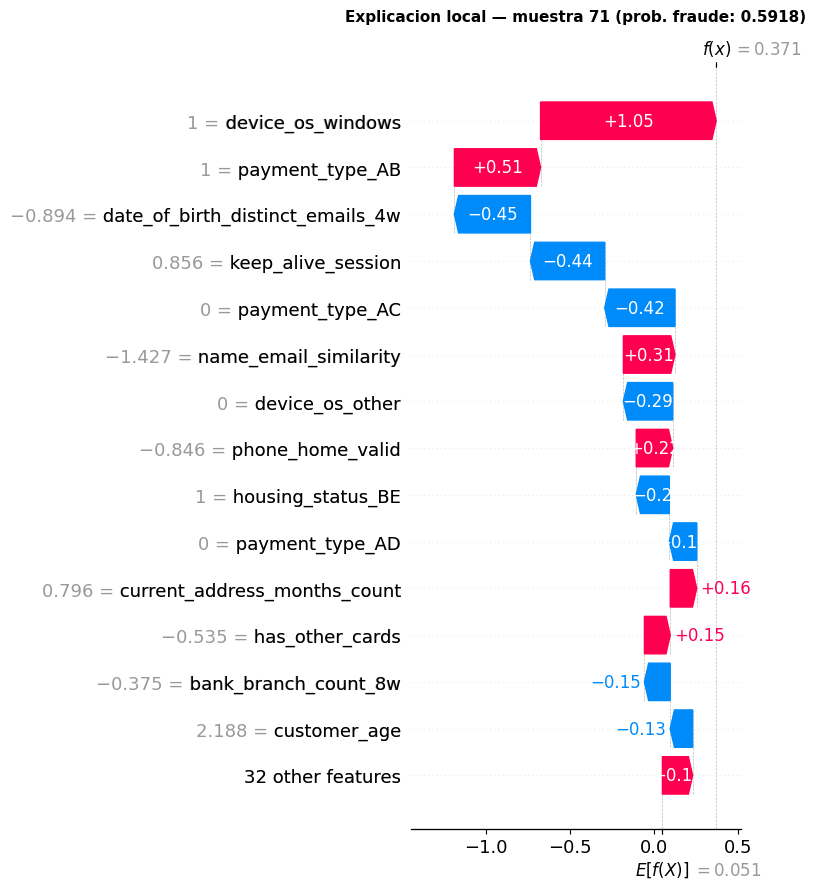

Grafico guardado en ../figures/shap_waterfall.png


In [9]:
# Calcular la explicacion SHAP para esa muestra concreta
# Hay que usar el objeto Explanation (no los shap_vals en bruto)
explicacion = explainer(X_shap, check_additivity=False)

# Waterfall plot de esa muestra
plt.figure()
shap.plots.waterfall(explicacion[idx_local], max_display=15, show=False)
plt.title(f'Explicacion local — muestra {idx_local} '
          f'(prob. fraude: {y_prob_muestra[idx_local]:.4f})',
          fontsize=11, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('../figures/shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafico guardado en ../figures/shap_waterfall.png')

## 7. Analisis critico de los resultados

### Contexto de los resultados del modelo

Antes de interpretar los valores SHAP es necesario recordar el rendimiento real del modelo sobre el conjunto de test con desbalanceo original:

| Metrica | Modelo sin preprocesado (NB02) | Modelo con SMOTE (NB03) |
|---------|-------------------------------|-------------------------|
| Precision | 0.20 | pendiente de ejecucion |
| Recall | 0.28 | pendiente de ejecucion |
| F1-Score | 0.23 | pendiente de ejecucion |
| PR-AUC | 0.16 | pendiente de ejecucion |
| ROC-AUC | 0.89 | pendiente de ejecucion |

Estos valores deben tenerse presentes al interpretar SHAP: las variables que SHAP identifica como mas influyentes son aquellas en las que el modelo *se apoya*, no necesariamente las que tienen mayor capacidad discriminativa real. Un modelo con rendimiento moderado puede apoyarse mucho en variables que en realidad aportan ruido.

### Interpretacion metodologica

La metodologia de busqueda aleatoria con validacion cruzada 5-fold aplicada en NB03 es correcta pero tiene limitaciones:

1. **Espacio de busqueda muestreado**: con 50 iteraciones sobre un espacio combinatorio de 390.625 configuraciones posibles se cubre aproximadamente el 0.013% del espacio. La convergencia observada sugiere que se ha encontrado una buena region, pero no necesariamente el optimo global.

2. **Metrica de optimizacion**: se optimizo ROC-AUC durante la busqueda. Esta metrica puede ser engañosa en datasets muy desbalanceados porque los verdaderos negativos masivos inflan artificialmente el area bajo la curva. Una alternativa mas rigurosa seria optimizar PR-AUC directamente.

3. **SMOTE en validacion cruzada**: en la implementacion actual, SMOTE se aplica antes de la validacion cruzada, lo que significa que algunas muestras sinteticas del fold de validacion son interpolaciones de muestras del fold de entrenamiento. Esto puede producir una estimacion algo optimista del rendimiento en CV. La solucion estricta seria incluir SMOTE dentro del pipeline de cada fold, usando `imblearn.pipeline.Pipeline`, pero queda fuera del alcance de este proyecto.

### Limitaciones generales del sistema

1. **Datos sinteticos**: el dataset fue generado a partir de patrones reales pero sigue siendo sintetico. Los patrones aprendidos pueden no transferirse directamente a datos bancarios reales, donde la distribucion de fraudes cambia constantemente a medida que los defraudadores adaptan sus estrategias.

2. **Ausencia de variables temporales reales**: el dataset cubre 8 meses con distribucion no uniforme. No se ha realizado validacion temporal (entrenar en meses anteriores y evaluar en meses posteriores), que es la forma correcta de validar sistemas de deteccion de fraude en produccion.

3. **Umbral de decision**: el umbral del 50% usado por defecto no esta calibrado al coste de negocio real. En produccion, el umbral optimo dependeria de la relacion entre el coste de un falso positivo (cliente bloqueado injustamente) y el coste de un falso negativo (fraude no detectado), que tipicamente tiene un ratio de 1:5 a 1:20 en favor de detectar el fraude.

## 8. Conclusiones del analisis de explicabilidad

El analisis SHAP cumple dos funciones complementarias en el sistema GuardianAI:

**A nivel global**, el summary plot permite identificar que variables son las mas influyentes en las decisiones del modelo y en que direccion actuan. Esto es util para validar que el modelo aprende patrones que tienen sentido desde el punto de vista del dominio bancario — si el modelo se apoyase principalmente en variables sin logica de negocio, seria una señal de sobreajuste o de algun problema en el preprocesado.

**A nivel local**, el waterfall plot permite explicar cualquier prediccion individual de forma trazable: dado un caso de fraude bloqueado, es posible indicar exactamente que combinacion de variables activo la alerta y con que magnitud contribuyo cada una. Esto satisface dos requisitos criticos:

- **Regulatorio**: normativas como la GDPR exigen que las decisiones automatizadas que afectan a personas sean explicables y auditables.
- **Operativo**: los analistas de riesgo pueden revisar los casos frontera con contexto, en lugar de recibir simplemente un numero de probabilidad.

### Limitaciones de la explicabilidad en este proyecto

SHAP explica *lo que hace el modelo*, no *lo que deberia hacer*. Si el modelo tiene un rendimiento limitado (F1 ~ 0.23 sin SMOTE), la explicabilidad no lo corrige — simplemente hace transparente por que toma las decisiones que toma, correctas o no.

El valor real de SHAP en produccion se materializaria una vez que el modelo alcanzase un rendimiento aceptable mediante las mejoras propuestas: ajuste del umbral orientado a coste de negocio, optimizacion de todos los modelos candidatos, e ingenieria de caracteristicas adicional.